# 쿠팡 물류센터 사례 기반 종합실습
## Pandas · Matplotlib · 데이터 준비 · 그룹 연산 · MongoDB · 시계열 · Seaborn

> 본 노트북은 교육용으로 생성한 **가상의 쿠팡 물류센터 유사 시나리오 데이터**를 사용합니다. 실제 쿠팡 내부 데이터가 아닙니다.

---

## 1. 문제 정의

쿠팡 물류센터 운영팀은 최근 다음과 같은 문제를 겪고 있다고 가정합니다.

1. 일부 물류센터에서 **배송 지연률**이 증가하고 있다.
2. 특정 상품군과 배송 유형에서 **작업 처리시간**이 길어지고 있다.
3. 주문 데이터에는 결측치, 중복, 문자열 불일치, 이상치가 섞여 있어 바로 분석하기 어렵다.
4. 일자별 물동량, 날씨, 근무 가능 인원과 배송 지연 사이의 관계를 확인해야 한다.
5. 분석 결과를 CSV/JSON으로 저장하고, MongoDB 적재 흐름도 확인해야 한다.

### 최종 분석 목표

> 물류센터별, 상품군별, 배송유형별 배송 지연 요인을 진단하고, 개선 우선순위를 도출한다.

---

## 2. 과정별 포함 내용

| 장 | 주제 | 본 실습에서 확인할 내용 |
|---|---|---|
| 10장 | Pandas 데이터 로딩, 저장, 파일 형식 | CSV 로딩, 월별 CSV 수집, JSON/CSV 저장 |
| 11장 | Matplotlib 시각화 | 라인, 바, 히스토그램, 산점도 |
| 12장 | 데이터 준비하기 | 결측치, 이상치, 문자열 정리, 중복 제거, 병합 |
| 13장 | 데이터 수집과 그룹 연산 | concat, groupby, agg, transform, pivot_table |
| 14장 | MongoDB와 파이썬 연결 | pymongo 연결 예제, insert/find 흐름, 실패 시 fallback |
| 15장 | Pandas 시계열 | datetime 변환, resample, rolling, 시간대별 분석 |
| 16장 | Seaborn | boxplot, heatmap, scatterplot, barplot |

---

> **수정 안내**  
> 본 노트북은 기존 실습 흐름과 코드를 유지하면서, 각 주요 코드 셀 하단에 `# 결과 해석:` 주석을 추가한 버전입니다.  
> 주석은 출력 결과를 어떻게 읽고, 어떤 의사결정으로 연결해야 하는지 이해하는 데 초점을 둡니다.


# 0. 실습 데이터 설명

실습에는 다음 CSV 파일을 사용합니다.

| 파일 | 의미 |
|---|---|
| `coupang_orders_raw.csv` | 주문 단위 물류 처리 로그. 결측, 중복, 이상치, 문자열 불일치가 포함된 원천 데이터 |
| `coupang_centers.csv` | 물류센터 마스터 데이터. 센터명, 지역, 처리능력, 자동화 수준 포함 |
| `coupang_daily_weather.csv` | 일자·센터별 날씨와 근무 가능 인원 데이터 |
| `coupang_orders_YYYY-MM.csv` | 월별 주문 CSV. 데이터 수집과 concat 실습용 |

> 실무에서는 주문, 센터, 날씨, 인력 데이터가 서로 다른 시스템에서 수집되는 경우가 많습니다. 이번 실습은 이런 상황을 가정합니다.

# 1. 환경 준비

필요한 라이브러리를 불러옵니다.

- `pandas`: 데이터 로딩, 정리, 병합, 그룹 연산, 시계열
- `numpy`: 수치 계산
- `matplotlib`: 기본 시각화
- `seaborn`: 통계적 시각화

In [1]:
%matplotlib inline

from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("seaborn이 설치되어 있지 않습니다. 16장 실습 일부는 Matplotlib으로 대체하세요.")

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.unicode_minus"] = False

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn 사용 가능:", HAS_SEABORN)

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: Seaborn 그래프는 그룹 간 분포 차이, 상관관계, 범주별 패턴을 빠르게 비교하는 데 유용합니다.
# 결과 해석: 색상 또는 hue로 구분된 집단 간 차이가 실제 업무적으로 설명 가능한지 해석해야 합니다.

pandas: 2.3.3
numpy: 2.3.5
seaborn 사용 가능: True


In [2]:
import platform

path = "c:/fonts/malgun.ttf"
from matplotlib import font_manager, rc
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~') 

# ------------------------------------------------------------
# 데이터 경로 설정
# ------------------------------------------------------------
# 노트북과 같은 위치에 coupang_logistics_practice_data 폴더가 있거나,
# /mnt/data/coupang_logistics_practice_data 폴더가 있으면 자동으로 사용합니다.
# ------------------------------------------------------------

candidate_dirs = [
    Path("coupang_logistics_practice_data"),
    Path("/mnt/data/coupang_logistics_practice_data")
]

DATA_DIR = None
for d in candidate_dirs:
    if d.exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError("coupang_logistics_practice_data 폴더를 찾을 수 없습니다. CSV 파일을 노트북과 같은 폴더에 두세요.")

print("DATA_DIR =", DATA_DIR)
print("CSV files:")
for p in sorted(DATA_DIR.glob("*.csv")):
    print("-", p.name)

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.

DATA_DIR = coupang_logistics_practice_data
CSV files:
- coupang_centers.csv
- coupang_daily_weather.csv
- coupang_orders_2026-01.csv
- coupang_orders_2026-02.csv
- coupang_orders_2026-03.csv
- coupang_orders_2026-04.csv
- coupang_orders_raw.csv


# 10장. Pandas 데이터 로딩, 저장, 파일 형식

## 10-1. CSV 파일 로딩

가장 먼저 원천 주문 데이터, 센터 마스터, 날씨 데이터를 읽어옵니다.

실무 포인트:
- CSV는 사람이 읽기 쉬운 텍스트 기반 표 형식 파일입니다.
- 데이터 로딩 직후 `shape`, `head`, `info`, `describe`로 구조를 확인해야 합니다.

In [3]:
orders_raw = pd.read_csv(DATA_DIR / "coupang_orders_raw.csv")
centers = pd.read_csv(DATA_DIR / "coupang_centers.csv")
weather = pd.read_csv(DATA_DIR / "coupang_daily_weather.csv")

print("orders_raw:", orders_raw.shape)
print("centers:", centers.shape)
print("weather:", weather.shape)

display(orders_raw.head())
display(centers.head())
display(weather.head())

# 결과 해석: CSV 파일을 DataFrame으로 읽어오면 행과 열 구조를 가진 표 형태로 분석할 수 있습니다.
# 결과 해석: head(), info(), shape 결과를 통해 데이터가 의도한 컬럼과 건수로 로딩되었는지 먼저 확인합니다.
# 결과 해석: 날씨 데이터와 주문 데이터를 결합하면 외부 환경이 배송 지연이나 처리량에 미치는 영향을 탐색할 수 있습니다.

orders_raw: (5220, 18)
centers: (5, 10)
weather: (600, 8)


,order_id,order_datetime,promised_datetime,shipped_datetime,delivered_datetime,center_id,sku_category,customer_region,delivery_type,customer_type,item_count,order_amount,picking_minutes,packing_minutes,shipping_distance_km,courier_partner,return_flag,damage_flag
0,OD101230,2026-04-04 20:56:00,2026-04-05 20:56:00,2026-04-04 21:27:06,2026-04-05 14:29:11,FC01,패션,충청권,로켓배송,와우회원,4,44700.0,21.5,9.6,90.0,PartnerB,0,0
1,OD101367,2026-04-01 04:01:00,2026-04-02 04:01:00,2026-04-01 04:40:48,2026-04-01 21:07:19,FC05,식품,충청권,로켓배송,일반,1,19800.0,17.4,22.4,145.4,PartnerC,0,0
2,OD102381,2026-02-09 16:39:00,2026-02-10 16:39:00,2026-02-09 17:33:30,2026-02-10 14:38:07,FC03,전자기기,충청권,로켓배송,일반,4,203300.0,33.1,21.4,169.4,PartnerA,0,0
3,OD103965,2026-01-14 18:36:00,2026-01-15 18:36:00,2026-01-14 19:17:24,2026-01-15 11:26:06,FC03,반려동물,충청권,로켓배송,와우회원,4,24300.0,32.1,9.3,118.5,CLS,0,0
4,OD105163,2026-02-03 09:32:00,2026-02-03 21:32:00,2026-02-03 09:55:12,2026-02-04 01:04:35,FC02,패션,제주권,새벽배송,일반,2,21900.0,16.0,7.2,333.2,PartnerB,0,0


,center_id,center_name,city,province,capacity_orders_per_day,automation_level,workers_day_shift,workers_night_shift,lat,lon
0,FC01,서울동부FC,서울,서울특별시,9000,High,420,360,37.53,127.12
1,FC02,인천서부FC,인천,인천광역시,8200,Medium,390,340,37.48,126.66
2,FC03,대구북부FC,대구,대구광역시,5800,Medium,280,230,35.91,128.61
3,FC04,부산남부FC,부산,부산광역시,6400,Low,310,260,35.16,129.06
4,FC05,광주호남FC,광주,광주광역시,4200,Low,210,180,35.18,126.88


,date,center_id,avg_temp_c,rainfall_mm,snow_cm,holiday_flag,inbound_volume,available_workers
0,2026-01-01,FC01,-6.1,0.6,0.0,1,4985,678.0
1,2026-01-01,FC02,-2.2,1.8,0.0,1,6895,726.0
2,2026-01-01,FC03,-0.1,4.8,0.0,1,4516,436.0
3,2026-01-01,FC04,1.2,0.0,0.0,1,4071,558.0
4,2026-01-01,FC05,-2.4,2.7,0.0,1,2533,376.0


In [4]:
# 데이터 구조 확인
orders_raw.info()

# 결과 해석: 이 셀의 실행 결과는 앞 단계에서 만든 데이터를 확인하거나 다음 분석 단계로 넘기기 위한 중간 점검입니다.
# 결과 해석: 출력된 행 수, 컬럼명, 값의 범위가 예상과 맞는지 확인하는 것이 중요합니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5220 entries, 0 to 5219
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              5220 non-null   object 
 1   order_datetime        5220 non-null   object 
 2   promised_datetime     5220 non-null   object 
 3   shipped_datetime      5185 non-null   object 
 4   delivered_datetime    5172 non-null   object 
 5   center_id             5220 non-null   object 
 6   sku_category          5220 non-null   object 
 7   customer_region       5220 non-null   object 
 8   delivery_type         5220 non-null   object 
 9   customer_type         5220 non-null   object 
 10  item_count            5220 non-null   int64  
 11  order_amount          5220 non-null   object 
 12  picking_minutes       5220 non-null   float64
 13  packing_minutes       5178 non-null   float64
 14  shipping_distance_km  5220 non-null   float64
 15  courier_partner      

In [5]:
# 기초 통계 확인
# include='all'을 사용하면 문자형 컬럼도 함께 요약할 수 있습니다.
orders_raw.describe(include="all").T.head(20)

# 결과 해석: 이 셀의 실행 결과는 앞 단계에서 만든 데이터를 확인하거나 다음 분석 단계로 넘기기 위한 중간 점검입니다.
# 결과 해석: 출력된 행 수, 컬럼명, 값의 범위가 예상과 맞는지 확인하는 것이 중요합니다.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,5220,5200,OD100678,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_datetime,5220,5103,2026-04-22 11:46:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promised_datetime,5220,5107,2026-02-19 18:23:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipped_datetime,5185,5155,2026-03-10 18:12:36,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivered_datetime,5172,5149,2026-02-13 17:36:12,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
center_id,5220,15,FC01,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_category,5220,21,생활용품,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_region,5220,6,수도권,2184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_type,5220,3,로켓배송,2841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,5220,3,일반,2803,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10-2. 월별 CSV 수집 후 하나로 합치기

`coupang_orders_YYYY-MM.csv` 파일들은 월별로 분리된 주문 로그입니다.

실무에서는 월별·일별·센터별 파일을 수집한 뒤 하나의 DataFrame으로 합치는 일이 자주 발생합니다.
여기서는 `glob()`와 `pd.concat()`을 사용합니다.

In [6]:
monthly_files = sorted(DATA_DIR.glob("coupang_orders_2026-*.csv"))
monthly_files

# 결과 해석: 이 셀의 실행 결과는 앞 단계에서 만든 데이터를 확인하거나 다음 분석 단계로 넘기기 위한 중간 점검입니다.
# 결과 해석: 출력된 행 수, 컬럼명, 값의 범위가 예상과 맞는지 확인하는 것이 중요합니다.

[WindowsPath('coupang_logistics_practice_data/coupang_orders_2026-01.csv'),
 WindowsPath('coupang_logistics_practice_data/coupang_orders_2026-02.csv'),
 WindowsPath('coupang_logistics_practice_data/coupang_orders_2026-03.csv'),
 WindowsPath('coupang_logistics_practice_data/coupang_orders_2026-04.csv')]

In [7]:
# ------------------------------------------------------------
# 여러 CSV 수집 및 결합
# ------------------------------------------------------------
# - 각 파일을 읽어 DataFrame 리스트로 만든 뒤 concat합니다.
# - source_file 컬럼을 추가하면 나중에 원천 파일 추적이 가능합니다.
# ------------------------------------------------------------

monthly_frames = []
for path in monthly_files:
    tmp = pd.read_csv(path)
    tmp["source_file"] = path.name
    monthly_frames.append(tmp)

orders_collected = pd.concat(monthly_frames, ignore_index=True)

print("월별 파일 결합 결과:", orders_collected.shape)
display(orders_collected[["order_id", "order_datetime", "center_id", "source_file"]].head())

# 결과 해석: CSV 파일을 DataFrame으로 읽어오면 행과 열 구조를 가진 표 형태로 분석할 수 있습니다.
# 결과 해석: head(), info(), shape 결과를 통해 데이터가 의도한 컬럼과 건수로 로딩되었는지 먼저 확인합니다.
# 결과 해석: 여러 월별 데이터를 concat하면 기간 전체의 주문 흐름을 하나의 DataFrame에서 분석할 수 있습니다.
# 결과 해석: concat 후에는 월별 건수 합계와 전체 건수가 일치하는지 검증하는 것이 중요합니다.
# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.

월별 파일 결합 결과: (5220, 19)


,order_id,order_datetime,center_id,source_file
0,OD103965,2026-01-14 18:36:00,FC03,coupang_orders_2026-01.csv
1,OD105065,2026-01-14 15:07:00,FC01,coupang_orders_2026-01.csv
2,OD102066,2026-01-19 14:56:00,FC04,coupang_orders_2026-01.csv
3,OD102441,2026-01-28 12:59:00,FC01,coupang_orders_2026-01.csv
4,OD101151,2026-01-05 17:13:00,FC04,coupang_orders_2026-01.csv


In [8]:
# 원본 전체 파일과 월별 수집 파일의 행 수가 일치하는지 확인합니다.
print("orders_raw row count:", len(orders_raw))
print("orders_collected row count:", len(orders_collected))

# 결과 해석: 이 셀의 실행 결과는 앞 단계에서 만든 데이터를 확인하거나 다음 분석 단계로 넘기기 위한 중간 점검입니다.
# 결과 해석: 출력된 행 수, 컬럼명, 값의 범위가 예상과 맞는지 확인하는 것이 중요합니다.

orders_raw row count: 5220
orders_collected row count: 5220


# 12장. Pandas 데이터 준비하기: 다듬기, 변형, 병합

원천 데이터에는 다음 문제가 의도적으로 포함되어 있습니다.

1. `center_id` 앞뒤 공백, 소문자 혼입
2. `sku_category` 값 표기 불일치
3. `order_amount`에 원화 기호, 쉼표, 문자열 `missing` 혼입
4. 날짜 컬럼이 문자열 상태
5. 중복 주문 행 존재
6. 결측치 존재
7. 이상치 및 도메인 오류 존재

따라서 분석 전에 정리 작업이 필요합니다.

## 12-1. 원본 보존 및 작업 복사본 생성

데이터 정제의 첫 원칙은 **원본을 보존하고 복사본에서 작업하는 것**입니다.

In [9]:
orders = orders_collected.copy()
orders_original = orders_collected.copy()

orders.head()

# 결과 해석: 이 셀의 실행 결과는 앞 단계에서 만든 데이터를 확인하거나 다음 분석 단계로 넘기기 위한 중간 점검입니다.
# 결과 해석: 출력된 행 수, 컬럼명, 값의 범위가 예상과 맞는지 확인하는 것이 중요합니다.

,order_id,order_datetime,promised_datetime,shipped_datetime,delivered_datetime,center_id,sku_category,customer_region,delivery_type,customer_type,item_count,order_amount,picking_minutes,packing_minutes,shipping_distance_km,courier_partner,return_flag,damage_flag,source_file
0,OD103965,2026-01-14 18:36:00,2026-01-15 18:36:00,2026-01-14 19:17:24,2026-01-15 11:26:06,FC03,반려동물,충청권,로켓배송,와우회원,4,24300.0,32.1,9.3,118.5,CLS,0,0,coupang_orders_2026-01.csv
1,OD105065,2026-01-14 15:07:00,2026-01-15 15:07:00,2026-01-14 15:47:06,2026-01-15 09:08:34,FC01,식품,호남권,로켓배송,와우회원,4,42800.0,15.4,24.7,151.6,CLS,0,0,coupang_orders_2026-01.csv
2,OD102066,2026-01-19 14:56:00,2026-01-20 14:56:00,2026-01-19 16:13:30,2026-01-20 09:11:49,FC04,생활용품,강원권,로켓배송,와우회원,3,16600.0,41.2,36.3,138.8,PartnerB,0,1,coupang_orders_2026-01.csv
3,OD102441,2026-01-28 12:59:00,2026-01-29 12:59:00,2026-01-28 13:29:42,2026-01-29 08:21:57,FC01,식품,수도권,로켓배송,와우회원,3,14900.0,16.5,14.2,102.5,CLS,0,0,coupang_orders_2026-01.csv
4,OD101151,2026-01-05 17:13:00,2026-01-06 17:13:00,2026-01-05 18:43:42,2026-01-06 14:03:52,FC04,식품,제주권,로켓배송,일반,2,62600.0,64.1,26.6,248.9,CLS,0,0,coupang_orders_2026-01.csv


## 12-2. 중복 제거

중복은 집계 결과를 왜곡합니다.  
`order_id` 기준 중복을 확인하고, 완전 중복 또는 동일 주문 중복을 제거합니다.

In [10]:
# 전체 행 기준 완전 중복 개수
print("완전 중복 행 수:", orders.duplicated().sum())

# 주문 ID 기준 중복 개수
print("order_id 기준 중복 행 수:", orders.duplicated(subset=["order_id"]).sum())

orders[orders.duplicated(subset=["order_id"], keep=False)].sort_values("order_id").head(10)

# 결과 해석: 중복 행은 주문 건수, 지연율, 매출 합계 등을 과대 계산하게 만들 수 있으므로 반드시 제거 전후 건수를 비교합니다.

완전 중복 행 수: 20
order_id 기준 중복 행 수: 20


,order_id,order_datetime,promised_datetime,shipped_datetime,delivered_datetime,center_id,sku_category,customer_region,delivery_type,customer_type,item_count,order_amount,picking_minutes,packing_minutes,shipping_distance_km,courier_partner,return_flag,damage_flag,source_file
128,OD100078,2026-01-01 22:09:00,2026-01-02 10:09:00,2026-01-01 23:24:00,2026-01-02 12:02:11,FC04,생활용품,호남권,새벽배송,와우회원,3,37000.0,41.6,33.4,139.1,PartnerB,1,0,coupang_orders_2026-01.csv
829,OD100078,2026-01-01 22:09:00,2026-01-02 10:09:00,2026-01-01 23:24:00,2026-01-02 12:02:11,FC04,생활용품,호남권,새벽배송,와우회원,3,37000.0,41.6,33.4,139.1,PartnerB,1,0,coupang_orders_2026-01.csv
434,OD100387,2026-01-17 13:50:00,2026-01-19 13:50:00,2026-01-17 14:53:06,2026-01-19 02:10:04,FC02,생활용품,영남권,일반배송,일반,1,25900.0,48.7,14.4,182.0,PartnerC,0,0,coupang_orders_2026-01.csv
526,OD100387,2026-01-17 13:50:00,2026-01-19 13:50:00,2026-01-17 14:53:06,2026-01-19 02:10:04,FC02,생활용품,영남권,일반배송,일반,1,25900.0,48.7,14.4,182.0,PartnerC,0,0,coupang_orders_2026-01.csv
2248,OD100678,2026-02-21 18:49:00,2026-02-22 18:49:00,2026-02-21 19:20:48,2026-02-22 14:05:51,FC01,뷰티,수도권,로켓배송,일반,3,36500.0,25.7,6.1,59.3,CLS,0,0,coupang_orders_2026-02.csv
2445,OD100678,2026-02-21 18:49:00,2026-02-22 18:49:00,2026-02-21 19:20:48,2026-02-22 14:05:51,FC01,뷰티,수도권,로켓배송,일반,3,36500.0,25.7,6.1,59.3,CLS,0,0,coupang_orders_2026-02.csv
1851,OD100742,2026-02-08 17:05:00,2026-02-09 17:05:00,2026-02-08 19:09:12,2026-02-09 17:08:43,FC05,반려동물,제주권,로켓배송,와우회원,4,50900.0,65.5,58.7,324.5,PartnerA,0,0,coupang_orders_2026-02.csv
1935,OD100742,2026-02-08 17:05:00,2026-02-09 17:05:00,2026-02-08 19:09:12,2026-02-09 17:08:43,FC05,반려동물,제주권,로켓배송,와우회원,4,50900.0,65.5,58.7,324.5,PartnerA,0,0,coupang_orders_2026-02.csv
4450,OD100921,2026-04-13 09:04:00,2026-04-14 09:04:00,2026-04-13 09:53:36,2026-04-14 02:00:27,FC05,전자기기,강원권,로켓배송,일반,2,119000.0,26.6,23.0,162.7,CLS,0,0,coupang_orders_2026-04.csv
4556,OD100921,2026-04-13 09:04:00,2026-04-14 09:04:00,2026-04-13 09:53:36,2026-04-14 02:00:27,FC05,전자기기,강원권,로켓배송,일반,2,119000.0,26.6,23.0,162.7,CLS,0,0,coupang_orders_2026-04.csv


In [11]:
# order_id 기준 첫 번째 행만 유지합니다.
orders = orders.drop_duplicates(subset=["order_id"], keep="first").copy()
print("중복 제거 후:", orders.shape)

# 결과 해석: 중복 행은 주문 건수, 지연율, 매출 합계 등을 과대 계산하게 만들 수 있으므로 반드시 제거 전후 건수를 비교합니다.

중복 제거 후: (5200, 19)


## 12-3. 문자열 정리

문자열 불일치는 병합 실패와 잘못된 그룹 집계의 주요 원인입니다.

예:
- `FC01`, ` fc01 `, `fc01`은 같은 센터를 의미하지만 문자열이 다르면 다른 값으로 처리됩니다.
- `식품`, `FOOD`, `food`도 동일한 상품군으로 통일해야 합니다.

In [12]:
# center_id 정리: 공백 제거, 대문자 변환
orders["center_id_before"] = orders["center_id"]
orders["center_id"] = orders["center_id"].astype(str).str.strip().str.upper()

# sku_category 정리: 공백 제거 후 매핑
orders["sku_category_before"] = orders["sku_category"]
orders["sku_category_clean"] = orders["sku_category"].astype(str).str.strip()

category_map = {
    "FOOD": "식품",
    "food": "식품",
    "electronics": "전자기기",
    "daily": "생활용품",
    "fashion": "패션",
    "beauty": "뷰티",
    "pet": "반려동물",
    "books": "도서"
}

orders["sku_category"] = orders["sku_category_clean"].replace(category_map)
orders = orders.drop(columns=["sku_category_clean"])

print("정리 전 center_id 예시:")
display(orders[["center_id_before", "center_id"]].drop_duplicates().head(10))

print("정리 후 sku_category 값:")
display(orders["sku_category"].value_counts())

# 결과 해석: 중복 행은 주문 건수, 지연율, 매출 합계 등을 과대 계산하게 만들 수 있으므로 반드시 제거 전후 건수를 비교합니다.

정리 전 center_id 예시:


,center_id_before,center_id
0,FC03,FC03
1,FC01,FC01
2,FC04,FC04
5,FC05,FC05
7,FC02,FC02
35,FC02,FC02
36,fc02,FC02
60,fc01,FC01
170,FC05,FC05
358,FC01,FC01


정리 후 sku_category 값:


sku_category
생활용품    1385
식품      1258
패션       732
뷰티       562
전자기기     510
반려동물     441
도서       312
Name: count, dtype: int64

## 12-4. 금액 컬럼 숫자 변환

`order_amount`에는 `₩120,000`, `missing`, 숫자형 값이 섞여 있습니다.

분석을 위해 숫자만 남기고 `float`로 변환합니다.

In [13]:
# ------------------------------------------------------------
# 금액 문자열 정리 함수
# ------------------------------------------------------------
# - 원화 기호, 쉼표를 제거합니다.
# - 'missing'처럼 숫자로 바꿀 수 없는 값은 NaN으로 처리합니다.
# ------------------------------------------------------------

def parse_amount(x):
    if pd.isna(x):
        return np.nan
    text = str(x).strip()
    if text.lower() in ["missing", "nan", "none", ""]:
        return np.nan
    text = text.replace("₩", "").replace(",", "")
    try:
        return float(text)
    except ValueError:
        return np.nan

orders["order_amount_raw"] = orders["order_amount"]
orders["order_amount"] = orders["order_amount"].apply(parse_amount)

orders[["order_amount_raw", "order_amount"]].head(10)

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 금액 지표는 총합과 평균을 함께 봐야 합니다. 총합은 규모를, 평균은 주문당 특성을 보여줍니다.

,order_amount_raw,order_amount
0,24300.0,24300.0
1,42800.0,42800.0
2,16600.0,16600.0
3,14900.0,14900.0
4,62600.0,62600.0
5,51800.0,51800.0
6,31300.0,31300.0
7,74200.0,74200.0
8,39200.0,39200.0
9,37500.0,37500.0


## 12-5. 날짜 컬럼 변환

시계열 분석을 위해 문자열 날짜를 `datetime64`로 변환합니다.

In [14]:
datetime_cols = ["order_datetime", "promised_datetime", "shipped_datetime", "delivered_datetime"]

for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

orders[datetime_cols].dtypes

# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.
# 결과 해석: rolling 평균은 일별 변동성을 줄이고 전체 추세를 부드럽게 확인하는 데 유용합니다.
# 결과 해석: 날씨 데이터와 주문 데이터를 결합하면 외부 환경이 배송 지연이나 처리량에 미치는 영향을 탐색할 수 있습니다.

order_datetime        datetime64[ns]
promised_datetime     datetime64[ns]
shipped_datetime      datetime64[ns]
delivered_datetime    datetime64[ns]
dtype: object

## 12-6. 파생 변수 생성

물류 성과를 분석하기 위해 다음 지표를 생성합니다.

| 지표 | 의미 |
|---|---|
| `order_date` | 주문일 |
| `processing_minutes` | 주문부터 출고까지 걸린 시간 |
| `delivery_minutes` | 주문부터 배송 완료까지 걸린 시간 |
| `late_delivery_flag` | 약속 시간보다 늦게 배송되었는지 여부 |
| `total_work_minutes` | 피킹 + 패킹 시간 |

In [15]:
orders["order_date"] = orders["order_datetime"].dt.floor("D")
orders["order_hour"] = orders["order_datetime"].dt.hour
orders["order_weekday"] = orders["order_datetime"].dt.day_name()

orders["processing_minutes"] = (orders["shipped_datetime"] - orders["order_datetime"]).dt.total_seconds() / 60
orders["delivery_minutes"] = (orders["delivered_datetime"] - orders["order_datetime"]).dt.total_seconds() / 60
orders["late_delivery_flag"] = (orders["delivered_datetime"] > orders["promised_datetime"]).astype("float")
orders.loc[orders["delivered_datetime"].isna() | orders["promised_datetime"].isna(), "late_delivery_flag"] = np.nan

orders["total_work_minutes"] = orders["picking_minutes"] + orders["packing_minutes"]

orders[["order_id", "processing_minutes", "delivery_minutes", "late_delivery_flag", "total_work_minutes"]].head()

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.
# 결과 해석: rolling 평균은 일별 변동성을 줄이고 전체 추세를 부드럽게 확인하는 데 유용합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

,order_id,processing_minutes,delivery_minutes,late_delivery_flag,total_work_minutes
0,OD103965,41.4,1010.100000,0.0,41.4
1,OD105065,40.1,1081.566667,0.0,40.1
2,OD102066,77.5,1095.816667,0.0,77.5
3,OD102441,30.7,1162.950000,0.0,30.7
4,OD101151,90.7,1250.866667,0.0,90.7


## 12-7. 결측치 진단 및 처리

결측치 처리는 단순히 `fillna()`를 적용하는 것이 아니라, **결측의 의미**를 판단해야 합니다.

이번 실습에서는 다음 전략을 사용합니다.

| 컬럼 | 처리 전략 | 이유 |
|---|---|---|
| `packing_minutes` | 센터·상품군별 중앙값 대체 | 작업시간은 그룹별 특성이 다름 |
| `courier_partner` | `Unknown` 대체 | 범주형 결측을 별도 범주로 보존 |
| `order_amount` | 상품군별 중앙값 대체 + 결측 flag | 매출 분석에 필요하되 결측 여부도 신호로 보존 |
| `shipped_datetime`, `delivered_datetime` | 결측 flag 생성 | 아직 출고/배송되지 않았을 가능성 |

In [16]:
missing_report = pd.DataFrame({
    "missing_count": orders.isna().sum(),
    "missing_rate": orders.isna().mean()
}).sort_values("missing_rate", ascending=False)

missing_report.head(20)

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.
# 결과 해석: 센터별 비교에서는 물량, 지연율, 평균 처리시간, 외부 요인을 함께 고려해야 합니다.

,missing_count,missing_rate
late_delivery_flag,48,0.009231
delivered_datetime,48,0.009231
delivery_minutes,48,0.009231
total_work_minutes,42,0.008077
packing_minutes,42,0.008077
shipped_datetime,35,0.006731
processing_minutes,35,0.006731
courier_partner,25,0.004808
order_amount,16,0.003077
center_id_before,0,0.000000


In [17]:
# 결측 flag 생성
orders["packing_minutes_missing_flag"] = orders["packing_minutes"].isna().astype(int)
orders["amount_missing_flag"] = orders["order_amount"].isna().astype(int)
orders["shipped_missing_flag"] = orders["shipped_datetime"].isna().astype(int)
orders["delivered_missing_flag"] = orders["delivered_datetime"].isna().astype(int)

# 범주형 결측 처리
orders["courier_partner"] = orders["courier_partner"].fillna("Unknown")

# 수치형 결측 처리: 그룹별 중앙값
orders["packing_minutes"] = orders["packing_minutes"].fillna(
    orders.groupby(["center_id", "sku_category"])["packing_minutes"].transform("median")
)
orders["packing_minutes"] = orders["packing_minutes"].fillna(orders["packing_minutes"].median())

orders["order_amount"] = orders["order_amount"].fillna(
    orders.groupby("sku_category")["order_amount"].transform("median")
)
orders["order_amount"] = orders["order_amount"].fillna(orders["order_amount"].median())

# total_work_minutes 재계산
orders["total_work_minutes"] = orders["picking_minutes"] + orders["packing_minutes"]

orders[["packing_minutes_missing_flag", "amount_missing_flag", "shipped_missing_flag", "delivered_missing_flag"]].sum()

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.

packing_minutes_missing_flag    42
amount_missing_flag             16
shipped_missing_flag            35
delivered_missing_flag          48
dtype: int64

## 12-8. 이상치 및 도메인 오류 처리

이상치는 실제 가능한 특수 상황일 수도 있고, 오류일 수도 있습니다.

이번 실습의 처리 방침은 다음과 같습니다.

| 문제 | 판단 | 처리 |
|---|---|---|
| `packing_minutes < 0` | 도메인 오류 | flag 생성 후 중앙값 대체 |
| `processing_minutes < 0` | 시간 역전 오류 | flag 생성 후 NaN 처리 |
| `order_amount` 고액 | 실제 기업 주문 가능 | 제거하지 않고 flag + 로그변환 |
| `item_count` 대량 | 기업 주문 가능 | flag 생성 |

In [18]:
# 도메인 오류 flag
orders["invalid_packing_flag"] = (orders["packing_minutes"] < 0).astype(int)
orders.loc[orders["invalid_packing_flag"] == 1, "packing_minutes"] = np.nan
orders["packing_minutes"] = orders["packing_minutes"].fillna(
    orders.groupby(["center_id", "sku_category"])["packing_minutes"].transform("median")
)
orders["packing_minutes"] = orders["packing_minutes"].fillna(orders["packing_minutes"].median())

# 시간 역전 오류
orders["invalid_processing_time_flag"] = (orders["processing_minutes"] < 0).astype(int)
orders.loc[orders["invalid_processing_time_flag"] == 1, "processing_minutes"] = np.nan

# IQR 기준 금액 이상치 flag
q1 = orders["order_amount"].quantile(0.25)
q3 = orders["order_amount"].quantile(0.75)
iqr = q3 - q1
upper_amount = q3 + 1.5 * iqr

orders["amount_outlier_iqr_flag"] = (orders["order_amount"] > upper_amount).astype(int)
orders["amount_log1p"] = np.log1p(orders["order_amount"])
orders["item_count_outlier_flag"] = (orders["item_count"] > orders["item_count"].quantile(0.99)).astype(int)

orders[["invalid_packing_flag", "invalid_processing_time_flag", "amount_outlier_iqr_flag", "item_count_outlier_flag"]].sum()

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 이상치는 오류일 수도 있지만, 물류센터의 프로모션·폭주·특정 센터 이슈처럼 실제 업무 신호일 수도 있습니다.
# 결과 해석: 따라서 제거하기 전에 IQR, z-score, 박스플롯 등 탐지 기준과 업무 맥락을 함께 확인합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.

invalid_packing_flag              6
invalid_processing_time_flag      8
amount_outlier_iqr_flag         375
item_count_outlier_flag          44
dtype: int64

## 12-9. 센터·날씨 데이터 병합

물류 성과는 주문 데이터만으로 설명하기 어렵습니다.  
센터의 자동화 수준, 처리능력, 날씨, 근무 가능 인원과 결합해야 운영 관점의 해석이 가능합니다.

In [19]:
# weather 병합을 위해 주문일과 센터 ID 기준 키 생성
orders["date"] = orders["order_date"]

orders_merged = orders.merge(centers, on="center_id", how="left")
orders_merged = orders_merged.merge(weather, on=["date", "center_id"], how="left")

print("병합 후 데이터 크기:", orders_merged.shape)
orders_merged.head()

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 날씨 데이터와 주문 데이터를 결합하면 외부 환경이 배송 지연이나 처리량에 미치는 영향을 탐색할 수 있습니다.

병합 후 데이터 크기: (5200, 54)


,order_id,order_datetime,promised_datetime,shipped_datetime,delivered_datetime,center_id,sku_category,customer_region,delivery_type,customer_type,item_count,order_amount,picking_minutes,packing_minutes,shipping_distance_km,courier_partner,return_flag,damage_flag,source_file,center_id_before,sku_category_before,order_amount_raw,order_date,order_hour,order_weekday,processing_minutes,delivery_minutes,late_delivery_flag,total_work_minutes,packing_minutes_missing_flag,amount_missing_flag,shipped_missing_flag,delivered_missing_flag,invalid_packing_flag,invalid_processing_time_flag,amount_outlier_iqr_flag,amount_log1p,item_count_outlier_flag,date,center_name,city,province,capacity_orders_per_day,automation_level,workers_day_shift,workers_night_shift,lat,lon,avg_temp_c,rainfall_mm,snow_cm,holiday_flag,inbound_volume,available_workers
0,OD103965,2026-01-14 18:36:00,2026-01-15 18:36:00,2026-01-14 19:17:24,2026-01-15 11:26:06,FC03,반려동물,충청권,로켓배송,와우회원,4,24300.0,32.1,9.3,118.5,CLS,0,0,coupang_orders_2026-01.csv,FC03,반려동물,24300.0,2026-01-14,18,Wednesday,41.4,1010.100000,0.0,41.4,0,0,0,0,0,0,0,10.098273,0,2026-01-14,대구북부FC,대구,대구광역시,5800,Medium,280,230,35.91,128.61,2.7,0.2,0.0,0,4109,469.0
1,OD105065,2026-01-14 15:07:00,2026-01-15 15:07:00,2026-01-14 15:47:06,2026-01-15 09:08:34,FC01,식품,호남권,로켓배송,와우회원,4,42800.0,15.4,24.7,151.6,CLS,0,0,coupang_orders_2026-01.csv,FC01,식품,42800.0,2026-01-14,15,Wednesday,40.1,1081.566667,0.0,40.1,0,0,0,0,0,0,0,10.664317,0,2026-01-14,서울동부FC,서울,서울특별시,9000,High,420,360,37.53,127.12,0.2,1.5,0.0,0,6571,752.0
2,OD102066,2026-01-19 14:56:00,2026-01-20 14:56:00,2026-01-19 16:13:30,2026-01-20 09:11:49,FC04,생활용품,강원권,로켓배송,와우회원,3,16600.0,41.2,36.3,138.8,PartnerB,0,1,coupang_orders_2026-01.csv,FC04,생활용품,16600.0,2026-01-19,14,Monday,77.5,1095.816667,0.0,77.5,0,0,0,0,0,0,0,9.717218,0,2026-01-19,부산남부FC,부산,부산광역시,6400,Low,310,260,35.16,129.06,3.4,1.2,0.0,0,4592,571.0
3,OD102441,2026-01-28 12:59:00,2026-01-29 12:59:00,2026-01-28 13:29:42,2026-01-29 08:21:57,FC01,식품,수도권,로켓배송,와우회원,3,14900.0,16.5,14.2,102.5,CLS,0,0,coupang_orders_2026-01.csv,FC01,식품,14900.0,2026-01-28,12,Wednesday,30.7,1162.950000,0.0,30.7,0,0,0,0,0,0,0,9.609184,0,2026-01-28,서울동부FC,서울,서울특별시,9000,High,420,360,37.53,127.12,2.3,0.0,0.0,0,7058,746.0
4,OD101151,2026-01-05 17:13:00,2026-01-06 17:13:00,2026-01-05 18:43:42,2026-01-06 14:03:52,FC04,식품,제주권,로켓배송,일반,2,62600.0,64.1,26.6,248.9,CLS,0,0,coupang_orders_2026-01.csv,FC04,식품,62600.0,2026-01-05,17,Monday,90.7,1250.866667,0.0,90.7,0,0,0,0,0,0,0,11.044537,0,2026-01-05,부산남부FC,부산,부산광역시,6400,Low,310,260,35.16,129.06,4.4,0.2,0.0,0,5628,475.0


In [20]:
# 병합 누락 확인
merge_check = pd.DataFrame({
    "missing_count": orders_merged[["center_name", "avg_temp_c", "rainfall_mm", "available_workers"]].isna().sum(),
    "missing_rate": orders_merged[["center_name", "avg_temp_c", "rainfall_mm", "available_workers"]].isna().mean()
})
merge_check

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 날씨 데이터와 주문 데이터를 결합하면 외부 환경이 배송 지연이나 처리량에 미치는 영향을 탐색할 수 있습니다.

,missing_count,missing_rate
center_name,0,0.000000
avg_temp_c,0,0.000000
rainfall_mm,109,0.020962
available_workers,64,0.012308


In [21]:
# 병합 후 날씨 결측 처리
orders_merged["rainfall_mm"] = orders_merged["rainfall_mm"].fillna(orders_merged["rainfall_mm"].median())
orders_merged["snow_cm"] = orders_merged["snow_cm"].fillna(0)
orders_merged["available_workers"] = orders_merged["available_workers"].fillna(
    orders_merged.groupby("center_id")["available_workers"].transform("median")
)
orders_merged["available_workers"] = orders_merged["available_workers"].fillna(orders_merged["available_workers"].median())

orders_merged[["rainfall_mm", "snow_cm", "available_workers"]].isna().sum()

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.

rainfall_mm          0
snow_cm              0
available_workers    0
dtype: int64

# 13장. Pandas 데이터 수집과 그룹 연산

## 13-1. 센터별 핵심 KPI 집계

물류센터 운영 분석에서 자주 보는 KPI는 다음과 같습니다.

| KPI | 의미 |
|---|---|
| 주문 수 | 처리 물량 |
| 지연률 | 약속 시간 초과 비율 |
| 평균 작업시간 | 피킹+패킹 효율 |
| 평균 배송시간 | 고객 체감 배송 속도 |
| 파손률 | 품질 문제 |
| 반품률 | 상품/배송 품질 문제 |

In [22]:
center_kpi = orders_merged.groupby(["center_id", "center_name"]).agg(
    order_count=("order_id", "count"),
    late_rate=("late_delivery_flag", "mean"),
    avg_processing_minutes=("processing_minutes", "mean"),
    avg_delivery_minutes=("delivery_minutes", "mean"),
    avg_work_minutes=("total_work_minutes", "mean"),
    damage_rate=("damage_flag", "mean"),
    return_rate=("return_flag", "mean"),
    avg_rainfall=("rainfall_mm", "mean"),
    avg_workers=("available_workers", "mean")
).reset_index()

center_kpi.sort_values("late_rate", ascending=False)

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

,center_id,center_name,order_count,late_rate,avg_processing_minutes,avg_delivery_minutes,avg_work_minutes,damage_rate,return_rate,avg_rainfall,avg_workers
4,FC05,광주호남FC,506,0.203187,52.364671,1239.088247,52.329545,0.023715,0.055336,2.018775,356.005929
1,FC02,인천서부FC,1376,0.193124,42.626794,1218.631102,42.752281,0.015988,0.053052,1.818241,673.314680
0,FC01,서울동부FC,1582,0.187540,37.311125,1197.209737,37.641200,0.015171,0.057522,1.792541,718.611884
2,FC03,대구북부FC,858,0.183649,44.132588,1238.871505,45.065647,0.015152,0.053613,2.276340,460.177156
3,FC04,부산남부FC,878,0.175520,50.226413,1226.977002,50.224203,0.021640,0.059226,1.886105,521.669704


## 13-2. 상품군·배송유형별 KPI

센터 전체 평균만 보면 문제 원인을 놓칠 수 있습니다.  
상품군과 배송유형을 함께 그룹화하여 어떤 조합에서 지연이 많은지 확인합니다.

In [23]:
category_delivery_kpi = orders_merged.groupby(["sku_category", "delivery_type"]).agg(
    order_count=("order_id", "count"),
    late_rate=("late_delivery_flag", "mean"),
    avg_amount=("order_amount", "mean"),
    avg_work_minutes=("total_work_minutes", "mean"),
    return_rate=("return_flag", "mean")
).reset_index()

category_delivery_kpi.sort_values(["late_rate", "order_count"], ascending=[False, False]).head(15)

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

,sku_category,delivery_type,order_count,late_rate,avg_amount,avg_work_minutes,return_rate
1,도서,새벽배송,83,0.719512,37584.337349,41.493976,0.024096
4,반려동물,새벽배송,112,0.702703,71523.214286,42.718750,0.026786
19,패션,새벽배송,208,0.643902,77628.365385,41.497115,0.144231
10,생활용품,새벽배송,363,0.643454,62999.173554,43.896143,0.063361
13,식품,새벽배송,325,0.624224,57617.846154,43.628898,0.036923
16,전자기기,새벽배송,131,0.558140,168285.496183,42.125573,0.061069
7,뷰티,새벽배송,136,0.555556,69829.044118,46.234881,0.051471
15,전자기기,로켓배송,271,0.059259,181914.022140,45.635550,0.073801
3,반려동물,로켓배송,245,0.057851,68093.061224,44.352964,0.036735
0,도서,로켓배송,166,0.049383,108442.168675,44.845783,0.042169


## 13-3. transform으로 센터 평균 대비 차이 계산

`transform`은 그룹별 계산 결과를 원래 행 개수와 같은 길이로 돌려줍니다.

예: 각 주문의 작업시간이 해당 센터 평균보다 얼마나 긴지 계산합니다.

In [24]:
orders_merged["center_avg_work_minutes"] = orders_merged.groupby("center_id")["total_work_minutes"].transform("mean")
orders_merged["work_minutes_vs_center_avg"] = orders_merged["total_work_minutes"] - orders_merged["center_avg_work_minutes"]

orders_merged[["order_id", "center_id", "total_work_minutes", "center_avg_work_minutes", "work_minutes_vs_center_avg"]].head()

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.

,order_id,center_id,total_work_minutes,center_avg_work_minutes,work_minutes_vs_center_avg
0,OD103965,FC03,41.4,45.065647,-3.665647
1,OD105065,FC01,40.1,37.641200,2.458800
2,OD102066,FC04,77.5,50.224203,27.275797
3,OD102441,FC01,30.7,37.641200,-6.941200
4,OD101151,FC04,90.7,50.224203,40.475797


## 13-4. pivot_table로 센터 × 배송유형 지연률 행렬 만들기

피벗 테이블은 행과 열 기준으로 집계 결과를 재구성할 때 유용합니다.

In [25]:
late_pivot = pd.pivot_table(
    orders_merged,
    values="late_delivery_flag",
    index="center_name",
    columns="delivery_type",
    aggfunc="mean"
)

late_pivot

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

delivery_type,로켓배송,새벽배송,일반배송
center_name,,,
광주호남FC,0.067164,0.661417,0.0
대구북부FC,0.041667,0.681818,0.0
부산남부FC,0.031056,0.631336,0.0
서울동부FC,0.042755,0.595402,0.0
인천서부FC,0.042466,0.636612,0.0


# 15장. Pandas 시계열

## 15-1. 일자별 주문량과 지연률

주문 데이터를 날짜 인덱스로 변환하여 일별 추세를 확인합니다.

In [26]:
ts = orders_merged.set_index("order_datetime").sort_index()

daily_kpi = ts.resample("D").agg(
    order_count=("order_id", "count"),
    late_rate=("late_delivery_flag", "mean"),
    avg_delivery_minutes=("delivery_minutes", "mean"),
    avg_rainfall=("rainfall_mm", "mean"),
    avg_workers=("available_workers", "mean")
)

daily_kpi.head()

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.

,order_count,late_rate,avg_delivery_minutes,avg_rainfall,avg_workers
order_datetime,,,,,
2026-01-01,42,0.333333,1234.028571,1.942857,583.619048
2026-01-02,49,0.142857,1310.502381,1.648980,581.510204
2026-01-03,46,0.200000,1283.328148,3.273913,596.565217
2026-01-04,30,0.300000,1156.280556,1.150000,631.600000
2026-01-05,46,0.200000,1256.618889,1.197826,578.521739


In [27]:
# 7일 이동평균 계산
# 이동평균은 일별 변동을 부드럽게 만들어 추세를 보기 쉽게 합니다.

daily_kpi["late_rate_7d_ma"] = daily_kpi["late_rate"].rolling(7, min_periods=1).mean()
daily_kpi["order_count_7d_ma"] = daily_kpi["order_count"].rolling(7, min_periods=1).mean()

daily_kpi.tail()

# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.
# 결과 해석: rolling 평균은 일별 변동성을 줄이고 전체 추세를 부드럽게 확인하는 데 유용합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.

,order_count,late_rate,avg_delivery_minutes,avg_rainfall,avg_workers,late_rate_7d_ma,order_count_7d_ma
order_datetime,,,,,,,
2026-04-26,37,0.243243,1285.760811,0.716216,562.351351,0.196188,42.000000
2026-04-27,48,0.130435,1280.652536,0.408333,575.125000,0.189425,42.428571
2026-04-28,36,0.171429,1201.177143,2.797222,544.750000,0.189425,42.428571
2026-04-29,53,0.211538,1062.093590,2.758491,606.528302,0.193670,42.142857
2026-04-30,44,0.159091,1213.519697,0.147727,598.750000,0.198976,42.142857


In [28]:
# 시간대별 주문량과 지연률
hourly_kpi = orders_merged.groupby("order_hour").agg(
    order_count=("order_id", "count"),
    late_rate=("late_delivery_flag", "mean"),
    avg_work_minutes=("total_work_minutes", "mean")
).reset_index()

hourly_kpi.head()

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 그룹 연산 결과는 센터별, 배송유형별, 시간대별 성과 차이를 비교하는 데 사용됩니다.
# 결과 해석: 평균만 보면 물량 차이를 놓칠 수 있으므로 count, sum, mean, rate를 함께 해석하는 것이 좋습니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

,order_hour,order_count,late_rate,avg_work_minutes
0,0,115,0.289474,45.211970
1,1,45,0.093023,45.557778
2,2,41,0.275000,40.260976
3,3,50,0.080000,45.940000
4,4,92,0.200000,45.242391


# 11장. Matplotlib 시각화

Matplotlib을 사용해 기본 그래프를 그립니다.

이번 실습에서는 다음 질문에 답합니다.

1. 일별 주문량과 지연률은 어떤 추세를 보이는가?
2. 어느 센터의 지연률이 높은가?
3. 배송시간 분포는 어떤 모양인가?
4. 물량과 지연률은 관계가 있는가?

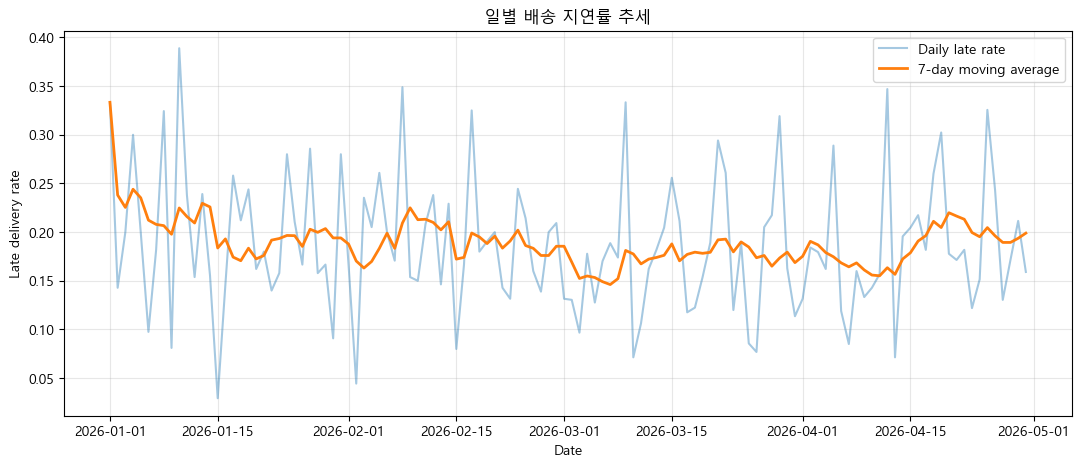

In [29]:
# 라인 그래프: 일별 지연률과 7일 이동평균
plt.figure(figsize=(13, 5))
plt.plot(daily_kpi.index, daily_kpi["late_rate"], label="Daily late rate", alpha=0.4)
plt.plot(daily_kpi.index, daily_kpi["late_rate_7d_ma"], label="7-day moving average", linewidth=2)
plt.title("일별 배송 지연률 추세")
plt.xlabel("Date")
plt.ylabel("Late delivery rate")
plt.legend()
plt.show()

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.

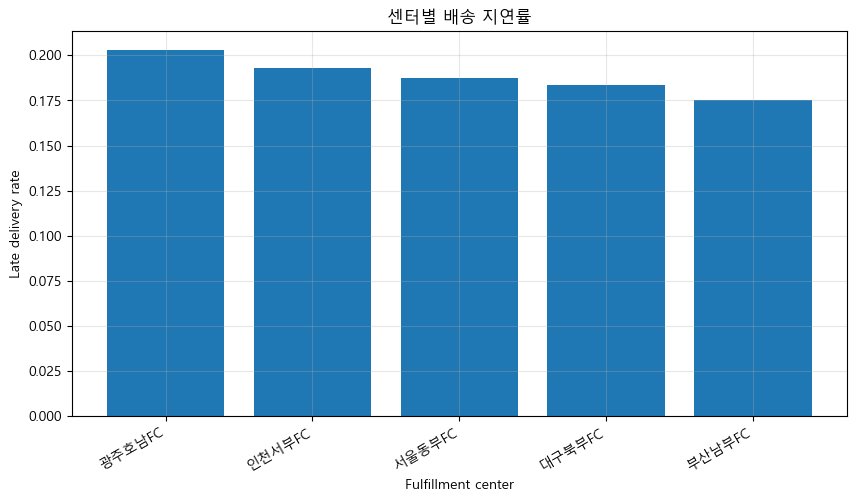

In [30]:
# 바 그래프: 센터별 지연률
center_kpi_sorted = center_kpi.sort_values("late_rate", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(center_kpi_sorted["center_name"], center_kpi_sorted["late_rate"])
plt.title("센터별 배송 지연률")
plt.xlabel("Fulfillment center")
plt.ylabel("Late delivery rate")
plt.xticks(rotation=30, ha="right")
plt.show()

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.

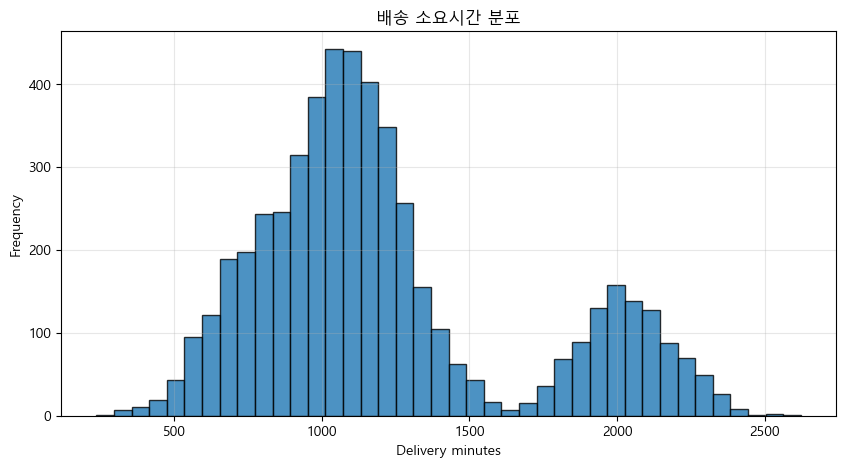

In [31]:
# 히스토그램: 배송시간 분포
plt.figure(figsize=(10, 5))
plt.hist(orders_merged["delivery_minutes"].dropna(), bins=40, edgecolor="black", alpha=0.8)
plt.title("배송 소요시간 분포")
plt.xlabel("Delivery minutes")
plt.ylabel("Frequency")
plt.show()

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.

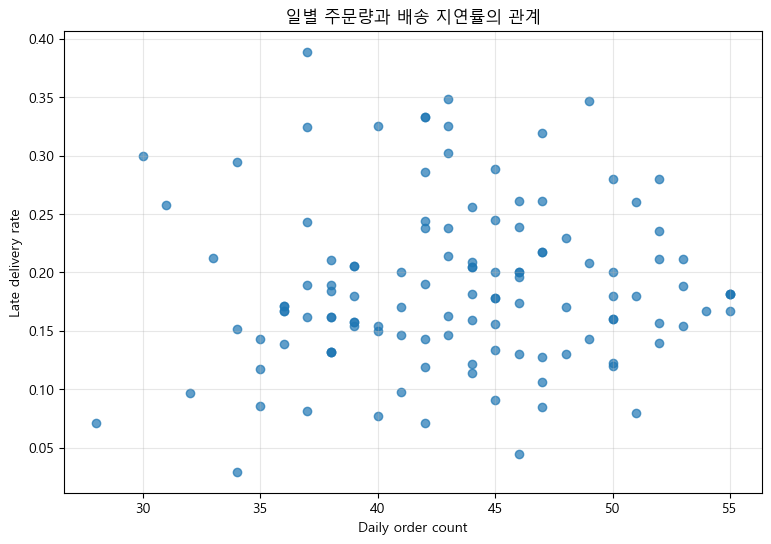

In [32]:
# 산점도: 일별 주문량과 지연률 관계
plt.figure(figsize=(9, 6))
plt.scatter(daily_kpi["order_count"], daily_kpi["late_rate"], alpha=0.7)
plt.title("일별 주문량과 배송 지연률의 관계")
plt.xlabel("Daily order count")
plt.ylabel("Late delivery rate")
plt.show()

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.

# 16장. Seaborn 시각화

Seaborn은 Pandas DataFrame과 잘 어울리는 통계 시각화 도구입니다.

Matplotlib보다 간결한 코드로 다음과 같은 그래프를 그릴 수 있습니다.

- 카테고리별 분포 비교
- 상관관계 히트맵
- 산점도와 회귀선
- 그룹별 막대그래프

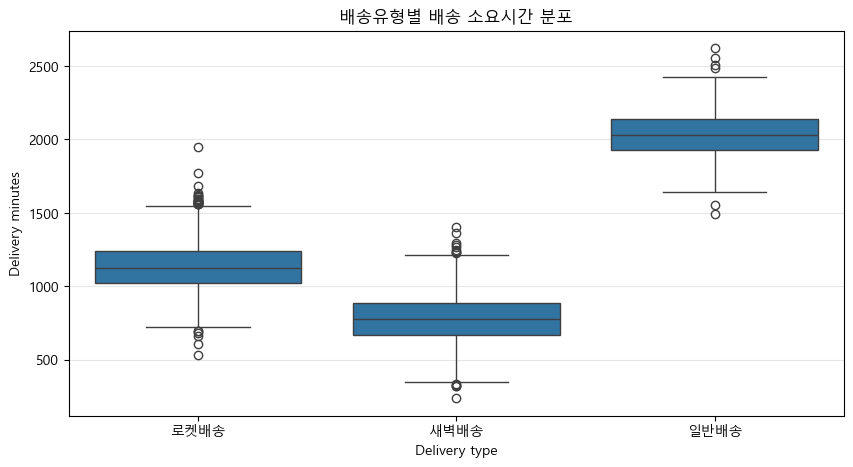

In [33]:
if HAS_SEABORN:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=orders_merged, x="delivery_type", y="delivery_minutes")
    plt.title("배송유형별 배송 소요시간 분포")
    plt.xlabel("Delivery type")
    plt.ylabel("Delivery minutes")
    plt.show()
else:
    print("seaborn이 없어 이 셀은 건너뜁니다.")

# 결과 해석: 이상치는 오류일 수도 있지만, 물류센터의 프로모션·폭주·특정 센터 이슈처럼 실제 업무 신호일 수도 있습니다.
# 결과 해석: 따라서 제거하기 전에 IQR, z-score, 박스플롯 등 탐지 기준과 업무 맥락을 함께 확인합니다.
# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.

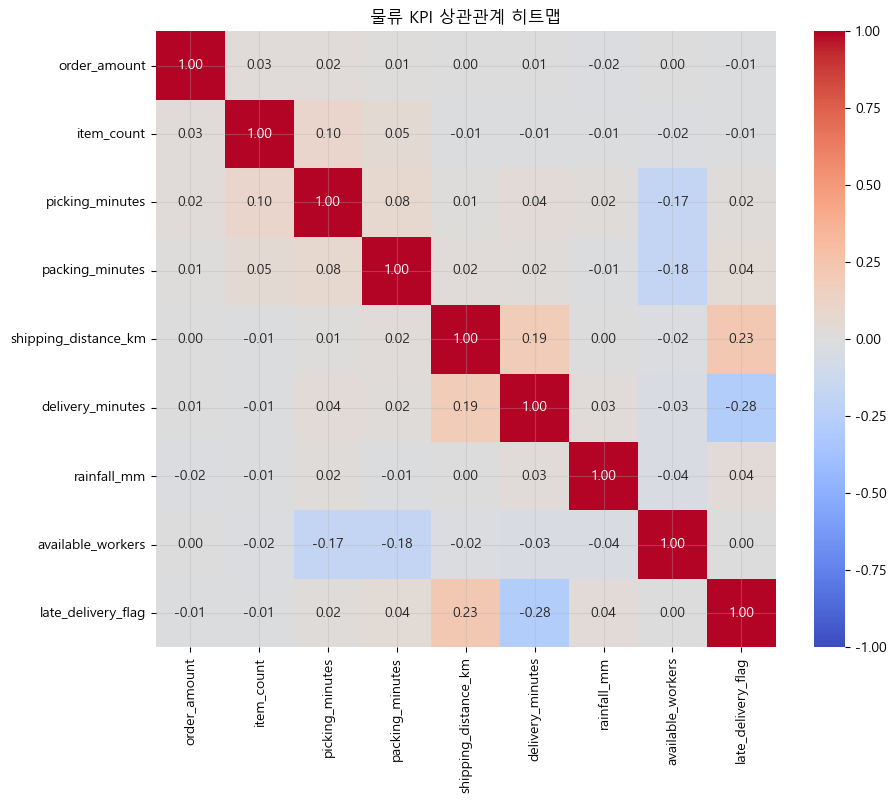

In [34]:
if HAS_SEABORN:
    corr_cols = [
        "order_amount", "item_count", "picking_minutes", "packing_minutes",
        "shipping_distance_km", "delivery_minutes", "rainfall_mm", "available_workers", "late_delivery_flag"
    ]
    corr = orders_merged[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("물류 KPI 상관관계 히트맵")
    plt.show()
else:
    print("seaborn이 없어 이 셀은 건너뜁니다.")

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: Seaborn 그래프는 그룹 간 분포 차이, 상관관계, 범주별 패턴을 빠르게 비교하는 데 유용합니다.

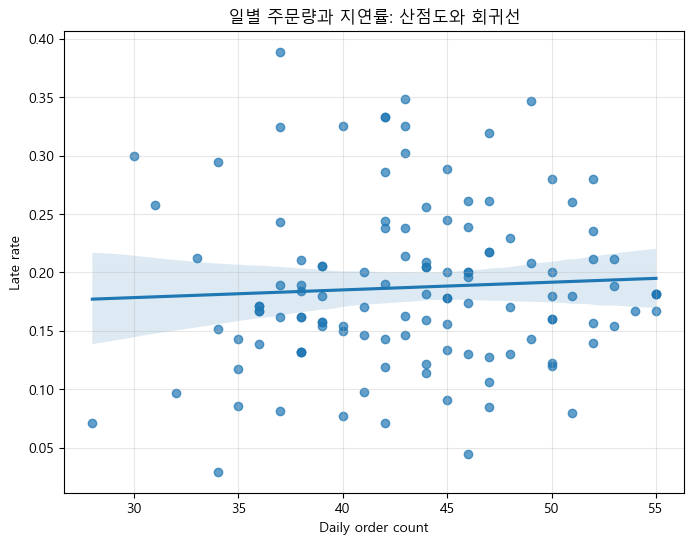

In [35]:
if HAS_SEABORN:
    sampled = daily_kpi.dropna().copy()
    plt.figure(figsize=(8, 6))
    sns.regplot(data=sampled, x="order_count", y="late_rate", scatter_kws={"alpha": 0.7})
    plt.title("일별 주문량과 지연률: 산점도와 회귀선")
    plt.xlabel("Daily order count")
    plt.ylabel("Late rate")
    plt.show()
else:
    print("seaborn이 없어 이 셀은 건너뜁니다.")

# 결과 해석: 결측치 결과는 단순히 비어 있는 값의 개수만 보는 것이 아니라, 어떤 컬럼과 어떤 그룹에 집중되는지 함께 해석해야 합니다.
# 결과 해석: 결측이 업무적으로 의미 있는 신호일 수 있으므로 대체 전 결측 여부 flag를 남기는 전략도 고려합니다.
# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: Seaborn 그래프는 그룹 간 분포 차이, 상관관계, 범주별 패턴을 빠르게 비교하는 데 유용합니다.

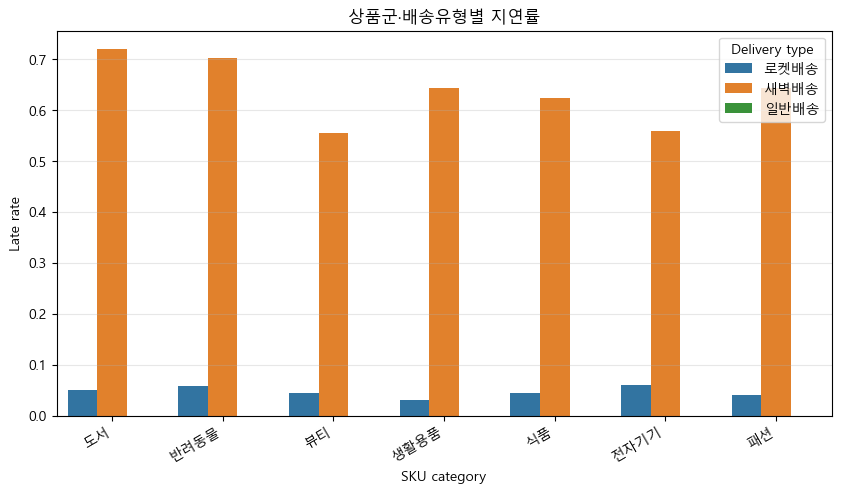

In [36]:
if HAS_SEABORN:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=category_delivery_kpi, x="sku_category", y="late_rate", hue="delivery_type")
    plt.title("상품군·배송유형별 지연률")
    plt.xlabel("SKU category")
    plt.ylabel("Late rate")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Delivery type")
    plt.show()
else:
    print("seaborn이 없어 이 셀은 건너뜁니다.")

# 결과 해석: Matplotlib 그래프는 수치 요약만으로 보이지 않는 추세, 분포, 관계를 직관적으로 확인하기 위한 도구입니다.
# 결과 해석: 그래프 해석 시에는 축 단위, 집계 기준, 이상치 포함 여부를 함께 확인해야 합니다.
# 결과 해석: Seaborn 그래프는 그룹 간 분포 차이, 상관관계, 범주별 패턴을 빠르게 비교하는 데 유용합니다.
# 결과 해석: 색상 또는 hue로 구분된 집단 간 차이가 실제 업무적으로 설명 가능한지 해석해야 합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.

# 14장. MongoDB와 파이썬 연결

## 14-1. MongoDB 적재 시나리오

실무에서는 정제된 데이터를 MongoDB 같은 NoSQL 데이터베이스에 저장하고, API 또는 분석 서비스에서 조회할 수 있습니다.

아래 코드는 다음 흐름을 보여줍니다.

1. 정제된 DataFrame 일부를 dictionary list로 변환
2. MongoDB 연결
3. collection에 적재
4. 조건 조회

> MongoDB 서버가 실행되어 있지 않아도 노트북이 실패하지 않도록 `try-except`를 사용합니다.

In [37]:
# MongoDB 적재용 샘플 데이터 생성
mongo_sample = orders_merged[[
    "order_id", "center_id", "center_name", "order_datetime", "sku_category",
    "delivery_type", "order_amount", "late_delivery_flag", "delivery_minutes"
]].head(20).copy()

# MongoDB는 Timestamp 타입을 직접 넣을 수 있지만, 실습 단순화를 위해 문자열로 변환합니다.
mongo_sample["order_datetime"] = mongo_sample["order_datetime"].astype(str)
records = mongo_sample.to_dict("records")

records[:2]

# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 시계열 처리 결과는 날짜·요일·시간대에 따른 물동량과 지연율 변화를 파악하기 위한 기반입니다.
# 결과 해석: rolling 평균은 일별 변동성을 줄이고 전체 추세를 부드럽게 확인하는 데 유용합니다.
# 결과 해석: MongoDB 실습은 반정형 문서 데이터를 조회한 뒤 Pandas DataFrame으로 변환하여 분석하는 흐름을 보여줍니다.

[{'order_id': 'OD103965',
  'center_id': 'FC03',
  'center_name': '대구북부FC',
  'order_datetime': '2026-01-14 18:36:00',
  'sku_category': '반려동물',
  'delivery_type': '로켓배송',
  'order_amount': 24300.0,
  'late_delivery_flag': 0.0,
  'delivery_minutes': 1010.1},
 {'order_id': 'OD105065',
  'center_id': 'FC01',
  'center_name': '서울동부FC',
  'order_datetime': '2026-01-14 15:07:00',
  'sku_category': '식품',
  'delivery_type': '로켓배송',
  'order_amount': 42800.0,
  'late_delivery_flag': 0.0,
  'delivery_minutes': 1081.5666666666666}]

In [38]:
# ------------------------------------------------------------
# MongoDB 연결 예제
# ------------------------------------------------------------
# 실행 조건:
# - 로컬 PC에 MongoDB가 설치되어 있고 실행 중이어야 합니다.
# - 기본 URI: mongodb://localhost:27017
#
# MongoDB가 없으면 except 블록으로 이동하여 실습 흐름만 확인합니다.
# ------------------------------------------------------------

try:
    from pymongo import MongoClient

    client = MongoClient("mongodb://localhost:27017", serverSelectionTimeoutMS=1000)
    client.server_info()  # 연결 확인

    db = client["logistics_training"]
    collection = db["coupang_orders_sample"]

    collection.delete_many({})
    collection.insert_many(records)

    query_result = list(collection.find({"late_delivery_flag": 1.0}, {"_id": 0}).limit(5))

    print("MongoDB 적재 성공")
    print("지연 배송 샘플 조회 결과:")
    display(pd.DataFrame(query_result))

except Exception as e:
    print("MongoDB 연결 또는 적재를 건너뜁니다.")
    print("이유:", type(e).__name__, str(e)[:200])
    print("대신 records 변수에 저장된 dictionary list를 확인합니다.")
    display(pd.DataFrame(records).head())

# 결과 해석: MongoDB 실습은 반정형 문서 데이터를 조회한 뒤 Pandas DataFrame으로 변환하여 분석하는 흐름을 보여줍니다.
# 결과 해석: 실제 운영 환경에서는 연결 실패, 인증 정보, 컬렉션 구조 차이를 고려해야 하므로 fallback 또는 예외 처리가 필요합니다.
# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 날씨 데이터와 주문 데이터를 결합하면 외부 환경이 배송 지연이나 처리량에 미치는 영향을 탐색할 수 있습니다.

MongoDB 적재 성공
지연 배송 샘플 조회 결과:


,order_id,center_id,center_name,order_datetime,sku_category,delivery_type,order_amount,late_delivery_flag,delivery_minutes
0,OD104048,FC05,광주호남FC,2026-01-21 14:40:00,생활용품,새벽배송,31300.0,1.0,784.666667
1,OD101960,FC02,인천서부FC,2026-01-22 14:29:00,식품,새벽배송,39200.0,1.0,832.116667
2,OD103003,FC01,서울동부FC,2026-01-29 17:59:00,전자기기,새벽배송,91900.0,1.0,1010.116667
3,OD102670,FC02,인천서부FC,2026-01-17 22:17:00,식품,새벽배송,32700.0,1.0,853.400000
4,OD103341,FC04,부산남부FC,2026-01-06 20:39:00,뷰티,새벽배송,29400.0,1.0,860.350000


# 10장 확장. 분석 결과 저장

정제 데이터와 KPI 결과를 CSV/JSON으로 저장합니다.

실무에서는 분석 과정에서 다음 파일을 남기는 것이 좋습니다.

1. 정제된 분석용 데이터
2. 집계 KPI 테이블
3. 모델 또는 대시보드 입력용 요약 데이터

In [39]:
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

cleaned_path = OUTPUT_DIR / "coupang_orders_cleaned.csv"
center_kpi_path = OUTPUT_DIR / "center_kpi.csv"
daily_kpi_path = OUTPUT_DIR / "daily_kpi.csv"
json_path = OUTPUT_DIR / "center_kpi.json"

orders_merged.to_csv(cleaned_path, index=False, encoding="utf-8-sig")
center_kpi.to_csv(center_kpi_path, index=False, encoding="utf-8-sig")
daily_kpi.reset_index().to_csv(daily_kpi_path, index=False, encoding="utf-8-sig")
center_kpi.to_json(json_path, orient="records", force_ascii=False, indent=2)

print("저장 완료")
print(cleaned_path)
print(center_kpi_path)
print(daily_kpi_path)
print(json_path)

# 결과 해석: 저장 결과는 전처리된 데이터를 다음 분석 단계나 보고서 작성에 재사용하기 위한 산출물입니다.
# 결과 해석: 파일 형식별로 장단점이 다르므로, 사람 검토용은 CSV/Excel, 분석 재사용은 JSON/Parquet 등을 고려할 수 있습니다.
# 결과 해석: 병합 결과는 주문 데이터에 센터, 날씨, 지역 등 외부 설명 변수를 붙여 원인 분석이 가능해졌다는 의미입니다.
# 결과 해석: 병합 후 행 수가 예상과 다르면 key 중복, 누락 key, join 방식 오류를 의심해야 합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.

저장 완료
coupang_logistics_practice_data\outputs\coupang_orders_cleaned.csv
coupang_logistics_practice_data\outputs\center_kpi.csv
coupang_logistics_practice_data\outputs\daily_kpi.csv
coupang_logistics_practice_data\outputs\center_kpi.json


# 종합 분석: 개선 우선순위 도출

이제 지금까지 만든 결과를 바탕으로 개선 우선순위를 정의합니다.

예시 기준:

1. 주문 수가 충분히 많다.
2. 지연률이 높다.
3. 평균 작업시간이 길다.
4. 파손률 또는 반품률이 높다.

아래에서는 간단한 우선순위 점수를 만들어 봅니다.

In [40]:
priority = center_kpi.copy()

# 순위 점수: 값이 높을수록 개선 필요성이 큰 지표
priority["late_rank"] = priority["late_rate"].rank(ascending=False)
priority["work_rank"] = priority["avg_work_minutes"].rank(ascending=False)
priority["damage_rank"] = priority["damage_rate"].rank(ascending=False)
priority["volume_rank"] = priority["order_count"].rank(ascending=False)

priority["priority_score"] = (
    priority["late_rank"] * 0.40 +
    priority["work_rank"] * 0.25 +
    priority["damage_rank"] * 0.20 +
    priority["volume_rank"] * 0.15
)

# rank는 1이 가장 높기 때문에 priority_score가 낮을수록 개선 우선순위가 높습니다.
priority = priority.sort_values("priority_score")
priority[["center_id", "center_name", "order_count", "late_rate", "avg_work_minutes", "damage_rate", "priority_score"]]

# 결과 해석: 배송 지연 관련 지표는 센터 운영 효율, 날씨, 주문량, 시간대 요인이 복합적으로 반영된 결과입니다.
# 결과 해석: 지연율은 지연 건수만이 아니라 전체 주문 수 대비 비율로 해석해야 센터 간 비교가 공정합니다.
# 결과 해석: 최종 요약 결과는 단순한 표 생성이 아니라, 개선 우선순위를 도출하기 위한 의사결정 자료로 해석합니다.
# 결과 해석: 센터별 비교에서는 물량, 지연율, 평균 처리시간, 외부 요인을 함께 고려해야 합니다.

,center_id,center_name,order_count,late_rate,avg_work_minutes,damage_rate,priority_score
4,FC05,광주호남FC,506,0.203187,52.329545,0.023715,1.60
1,FC02,인천서부FC,1376,0.193124,42.752281,0.015988,2.70
3,FC04,부산남부FC,878,0.175520,50.224203,0.021640,3.35
0,FC01,서울동부FC,1582,0.187540,37.641200,0.015171,3.40
2,FC03,대구북부FC,858,0.183649,45.065647,0.015152,3.95


## 해석 가이드

위 결과를 보고 다음 질문에 답해보세요.

1. 개선 우선순위가 가장 높은 센터는 어디인가요?
2. 그 센터는 지연률, 작업시간, 파손률 중 어떤 지표가 문제인가요?
3. 특정 배송유형이나 상품군이 문제를 크게 만들고 있나요?
4. 날씨, 근무 가능 인원, 물동량과 지연률 사이에 관계가 있나요?
5. 다음 액션은 인력 재배치, 자동화 보완, 특정 상품군 프로세스 개선 중 무엇이 적절할까요?